In [1]:
import sys

sys.path.insert(1, '../ML_pipeline')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.manifold import TSNE

### For our baseline model we will only consider four measurements: the mean heart rate, and the mean acceleration magnitudes from each of the three sensors. First we read in the features:

In [2]:
full_df = pd.read_csv('features.csv')

device_list = ['hand',
               'chest',
               'ankle']

axes_list = ['amp']

sensor_list = ['acc16']

stat_list = ['mean']

feature_list = []

for stat in stat_list:
    feature_list.append('heart_rate_'+stat)

for device in device_list:
    for sensor in sensor_list:
        
        for axis in axes_list:
            for stat in stat_list:
                label = '_'.join([device,sensor,axis,stat])
                feature_list.append(label)
    


X = full_df[feature_list]
y = full_df['activity_id']
groups = full_df['interval_id']

### We will consider three classification approaches: full activity classification (y), minimal grouping of similar activities (y_sim), and aggressive grouping of activities by low, medium, and high activity (y_LMH).

In [3]:
# creates new activity dataframe based on input groups
# group_dict is a dictionary where keys are the desired group labels and values are the lists of activity ids in the new group
def group_activities(y,group_dict):
    y_new = y.copy(deep=True)

    for group in group_dict.keys():
        for id in group_dict[group]:
            y_new.replace(to_replace=id,value=group,inplace=True)

    return y_new

name_map = {
        0: 'Transient/Break', 1: 'Lying down', 2: 'Sitting', 3: 'Standing', 
        4: 'Walking', 5: 'Running', 6: 'Cycling', 7: 'Nordic walking', 
        9: 'Watching TV', 10: 'Computer work', 11: 'Car driving', 
        12: 'Ascending stairs', 13: 'Descending stairs', 16: 'Vacuum cleaning', 
        17: 'Ironing', 18: 'Folding laundry', 19: 'House cleaning', 
        20: 'Playing soccer', 24: 'Rope jumping'
    }

'Similar activities grouping:'
sim_groups = {101:[1,2], #lying, sitting
              102:[4,7], #walking, nordic walking
              103:[16,17] #vacuum cleaning, ironing
              }
name_map_sim = {
    101: "Resting",
    3: "Standing",
    102: "Walking",
    5: "Running",
    6: "Cycling",
    9: "Watching TV",
    10: "Computer Work",
    11: "Car Driving",
    12: "Ascending \nStairs",
    13: "Descending \nStairs",
    103: "House Work",
    18: "Folding Laundry",
    19: "House Cleaning",
    20: "Playing Soccer",
    24: "Rope \nJumping",
}

y_sim = group_activities(y,sim_groups)

'Low/medium/high activity grouping:'
LMH_groups = {101:[1,2,3], #lying, sitting, standing
              102:[4,7,12,13,16,17], #walking, nordic walking, ascending stairs, descending stairs, vacuum cleaning, ironing
              103:[5,6,24] #running, cycling, rope jumping
              } 

name_map_LMH = {
    101: "Low \nActivity",
    102: "Medium \nActivity",
    103: "High \nActivity",
}

y_LMH = group_activities(y,LMH_groups)

### This is our function to perform and evaluate the fit. To classify a segment, we look at the normalized distance to the mean of each activity in the 4-dimensional feature space. The segment is assigned to the activity it is nearest to.

In [4]:
def fit_baseline(y):

    fold_rows = []
    all_true = []
    all_pred = []

    labels_sorted = np.sort(y.unique())
    gkf = GroupKFold(n_splits=5)

    for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groups), start=1):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        activities = y.unique()
        means = {}
        stds = {}

        for act in activities:
                mean = X_train[y_train==act].mean().values
                std = X_train[y_train==act].std().values
                means[act] = mean
                stds[act] = std


        means_arr = np.zeros([len(activities),1+len(means[activities[0]])])
        means_arr[:,0] = activities

        for j in range(means_arr.shape[0]):
                key = means_arr[j,0]
                means_arr[j,1:] = means[key]


        stds_arr = np.zeros([len(activities),1+len(stds[activities[0]])])
        stds_arr[:,0] = activities

        for j in range(stds_arr.shape[0]):
                key = stds_arr[j,0]
                stds_arr[j,1:] = stds[key]


        def test_row(row):
                test_arr = np.zeros(means_arr.shape)
                test_arr[:,0] = means_arr[:,0]
                test_arr[:,1:] = row.values
                test_arr[:,1:] -= means_arr[:,1:]
                test_arr[:,1:] = test_arr[:,1:] / stds_arr[:,1:]
                norms = np.linalg.norm(test_arr[:,1:],axis=1)
                ind_best = np.argmin(norms)

                return activities[ind_best]

        y_pred = X_test.apply(test_row,axis=1)

        acc = accuracy_score(y_test, y_pred)
        prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
            y_test,
            y_pred,
            average="macro",
            zero_division=0,
        )

        fold_rows.append(
            {
                "fold": fold_idx,
                "accuracy": acc,
                "macro_precision": prec_macro,
                "macro_recall": rec_macro,
                "macro_f1": f1_macro,
                "n_test": len(test_idx),
            }
        )

        all_true.append(y_test.to_numpy())
        all_pred.append(y_pred)

        print(
            f"Fold {fold_idx}: "
            f"acc={acc:.4f}, macro_f1={f1_macro:.4f}, n_test={len(test_idx)}"
        )

    cv_metrics = pd.DataFrame(fold_rows)
    print("\n5-fold metrics:")
    print(cv_metrics)

    print("\nAverage performance (5-fold):")
    print(
        cv_metrics[["accuracy", "macro_precision", "macro_recall", "macro_f1"]]
        .mean()
        .to_frame("mean")
        .join(
            cv_metrics[["accuracy", "macro_precision", "macro_recall", "macro_f1"]]
            .std(ddof=1)
            .to_frame("std")
        )
    )

    y_true_all = np.concatenate(all_true)
    y_pred_all = np.concatenate(all_pred)

    print("\nClassification report (all fold predictions combined):")
    print(classification_report(y_true_all, y_pred_all, labels=labels_sorted, zero_division=0))

    return y_true_all,y_pred_all,y_test,y_pred,labels_sorted

### Here we test our baseline model for each of the three classification approaches.

In [5]:
#testing with full activity list
y_true_all,y_pred_all,y_test,y_pred,labels = fit_baseline(y)

Fold 1: acc=0.5929, macro_f1=0.4118, n_test=3120
Fold 2: acc=0.5600, macro_f1=0.5194, n_test=3143
Fold 3: acc=0.3912, macro_f1=0.3070, n_test=3121
Fold 4: acc=0.4877, macro_f1=0.4541, n_test=3121
Fold 5: acc=0.4860, macro_f1=0.4190, n_test=3144

5-fold metrics:
   fold  accuracy  macro_precision  macro_recall  macro_f1  n_test
0     1  0.592949         0.446373      0.448755  0.411823    3120
1     2  0.559975         0.540792      0.584736  0.519398    3143
2     3  0.391221         0.441750      0.348523  0.307026    3121
3     4  0.487664         0.542866      0.513350  0.454113    3121
4     5  0.486005         0.449369      0.445517  0.418977    3144

Average performance (5-fold):
                     mean       std
accuracy         0.503563  0.078029
macro_precision  0.484230  0.052656
macro_recall     0.468176  0.087799
macro_f1         0.422267  0.077216

Classification report (all fold predictions combined):
              precision    recall  f1-score   support

         1.0  

In [6]:
#testing with similar activities grouped
y_true_all_sim,y_pred_all_sim,y_test_sim,y_pred_sim,labels_sim = fit_baseline(y_sim)

Fold 1: acc=0.6660, macro_f1=0.4293, n_test=3120
Fold 2: acc=0.5813, macro_f1=0.5428, n_test=3143
Fold 3: acc=0.3845, macro_f1=0.3172, n_test=3121
Fold 4: acc=0.6331, macro_f1=0.5581, n_test=3121
Fold 5: acc=0.5703, macro_f1=0.5045, n_test=3144

5-fold metrics:
   fold  accuracy  macro_precision  macro_recall  macro_f1  n_test
0     1  0.666026         0.422145      0.471033  0.429269    3120
1     2  0.581292         0.579295      0.622758  0.542798    3143
2     3  0.384492         0.457882      0.407794  0.317221    3121
3     4  0.633130         0.624122      0.625706  0.558091    3121
4     5  0.570293         0.562824      0.533044  0.504546    3144

Average performance (5-fold):
                     mean       std
accuracy         0.567047  0.109206
macro_precision  0.529254  0.085436
macro_recall     0.532067  0.095083
macro_f1         0.470385  0.099061

Classification report (all fold predictions combined):
              precision    recall  f1-score   support

         3.0  

In [7]:
#testing with low/medium/high groups
y_true_all_LMH,y_pred_all_LMH,y_test_LMH,y_pred_LMH,labels_LMH = fit_baseline(y_LMH)

Fold 1: acc=0.7788, macro_f1=0.7223, n_test=3120
Fold 2: acc=0.6863, macro_f1=0.6524, n_test=3143
Fold 3: acc=0.5463, macro_f1=0.5261, n_test=3121
Fold 4: acc=0.4726, macro_f1=0.4245, n_test=3121
Fold 5: acc=0.6848, macro_f1=0.6787, n_test=3144

5-fold metrics:
   fold  accuracy  macro_precision  macro_recall  macro_f1  n_test
0     1  0.778846         0.706158      0.847981  0.722312    3120
1     2  0.686287         0.649945      0.660373  0.652397    3143
2     3  0.546299         0.532095      0.613191  0.526130    3121
3     4  0.472605         0.573118      0.421178  0.424510    3121
4     5  0.684796         0.739212      0.749826  0.678671    3144

Average performance (5-fold):
                     mean       std
accuracy         0.633767  0.122509
macro_precision  0.640106  0.087229
macro_recall     0.658510  0.160173
macro_f1         0.600804  0.122623

Classification report (all fold predictions combined):
              precision    recall  f1-score   support

       101.0  

In [8]:
def plot_cm(y_true_all,y_pred_all,labels_sorted,activity_name_map,name):

    # Activity labels after class-combination:
    # 2 -> 1 (Resting), 7 -> 4 (Walking), 17 -> 16 (House Work)

    # Use combined-category names in confusion matrix axes.
    # activity_name_map = {
    #     0: 'Transient/Break', 1: 'Lying down', 2: 'Sitting', 3: 'Standing', 
    #     4: 'Walking', 5: 'Running', 6: 'Cycling', 7: 'Nordic walking', 
    #     9: 'Watching TV', 10: 'Computer work', 11: 'Car driving', 
    #     12: 'Ascending stairs', 13: 'Descending stairs', 16: 'Vacuum cleaning', 
    #     17: 'Ironing', 18: 'Folding laundry', 19: 'House cleaning', 
    #     20: 'Playing soccer', 24: 'Rope jumping'
    # }

    def _label_with_prefix(activity_id, prefix):
        name = activity_name_map.get(int(activity_id), f"ID{int(activity_id)}")
        return f"{name}"

    cm = pd.DataFrame(
        confusion_matrix(y_true_all, y_pred_all, labels=labels_sorted),
        index=[_label_with_prefix(lbl, "T") for lbl in labels_sorted],
        columns=[_label_with_prefix(lbl, "P") for lbl in labels_sorted],
    )

    print("\nConfusion matrix (5-fold pooled predictions):")
    print(cm)




    # Pretty, colorized confusion matrix saved as PNG.
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm.values, cmap="Blues")

    ax.set_xticks(np.arange(len(cm.columns)))
    ax.set_yticks(np.arange(len(cm.index)))
    ax.set_xticklabels(cm.columns, rotation=45, ha="right")
    ax.set_yticklabels(cm.index)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Baseline Model group K splitting Confusion Matrix ("+name+")")

    # Annotate each cell with count value.
    threshold = cm.values.max() / 2 if cm.values.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm.iat[i, j]
            color = "white" if value > threshold else "black"
            ax.text(j, i, str(value), ha="center", va="center", color=color, fontsize=9)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Count")
    fig.tight_layout()

    output_png = "baseline_group_K_split_confusion_matrix_"+name.split(' ')[0]+".png"
    fig.savefig(output_png, dpi=200, bbox_inches="tight")
    print(f"\nSaved confusion group K split matrix PNG: {output_png}")
    plt.show()

def plot_cm_test(y_test,y_pred,labels_sorted,activity_name_map,name):


    def _label_with_prefix(activity_id, prefix):
        name = activity_name_map.get(int(activity_id), f"ID{int(activity_id)}")
        return f"{name}"

    cm = pd.DataFrame(
        confusion_matrix(y_test, y_pred, labels=labels_sorted),
        index=[_label_with_prefix(lbl, "T") for lbl in labels_sorted],
        columns=[_label_with_prefix(lbl, "P") for lbl in labels_sorted],
    )

    print("\nConfusion matrix (test set):")
    print(cm)




    # Pretty, colorized confusion matrix saved as PNG.
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm.values, cmap="Blues")

    ax.set_xticks(np.arange(len(cm.columns)))
    ax.set_yticks(np.arange(len(cm.index)))
    ax.set_xticklabels(cm.columns, rotation=45, ha="right")
    ax.set_yticklabels(cm.index)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Baseline Confusion Matrix ("+name+")")

    # Annotate each cell with count value.
    threshold = cm.values.max() / 2 if cm.values.size else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm.iat[i, j]
            color = "white" if value > threshold else "black"
            ax.text(j, i, str(value), ha="center", va="center", color=color, fontsize=9)

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Count")
    fig.tight_layout()

    output_png = "baseline_confusion_matrix_"+name.split(' ')[0]+".png"
    fig.savefig(output_png, dpi=200, bbox_inches="tight")
    print(f"\nSaved confusion matrix PNG: {output_png}")
    plt.show()


Confusion matrix (5-fold pooled predictions):
                   Lying down  Sitting  Standing  Walking  Running  Cycling  \
Lying down               1415       30        11        0        0        0   
Sitting                   147      902       207        0        0        0   
Standing                    0      490       385        0        0        0   
Walking                     0        0         1      520        9        0   
Running                     0        1         0        2      740        0   
Cycling                     0        0         0        0        0      692   
Nordic walking              0        0         0       61        2        2   
Ascending stairs            0        0         0       22       21        2   
Descending stairs           0        0         2       14       50        0   
Vacuum cleaning             0        2         4        0        0       20   
Ironing                     0      237       157        0        0       14   
Rope 

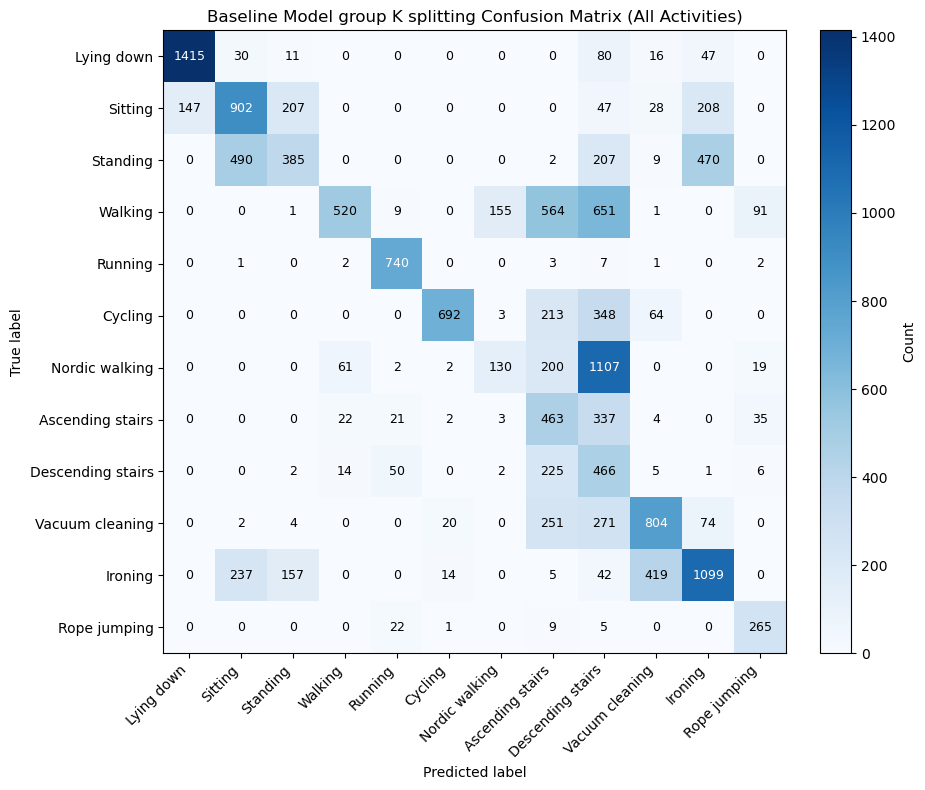


Confusion matrix (test set):
                   Lying down  Sitting  Standing  Walking  Running  Cycling  \
Lying down                414       25         4        0        0        0   
Sitting                    38      193         3        0        0        0   
Standing                    0      242         1        0        0        0   
Walking                     0        0         0      183        0        0   
Running                     0        1         0        1      253        0   
Cycling                     0        0         0        0        0      221   
Nordic walking              0        0         0       18        2        0   
Ascending stairs            0        0         0        5       18        0   
Descending stairs           0        0         2        2        0        0   
Vacuum cleaning             0        0         0        0        0        0   
Ironing                     0        0         0        0        0        0   
Rope jumping          

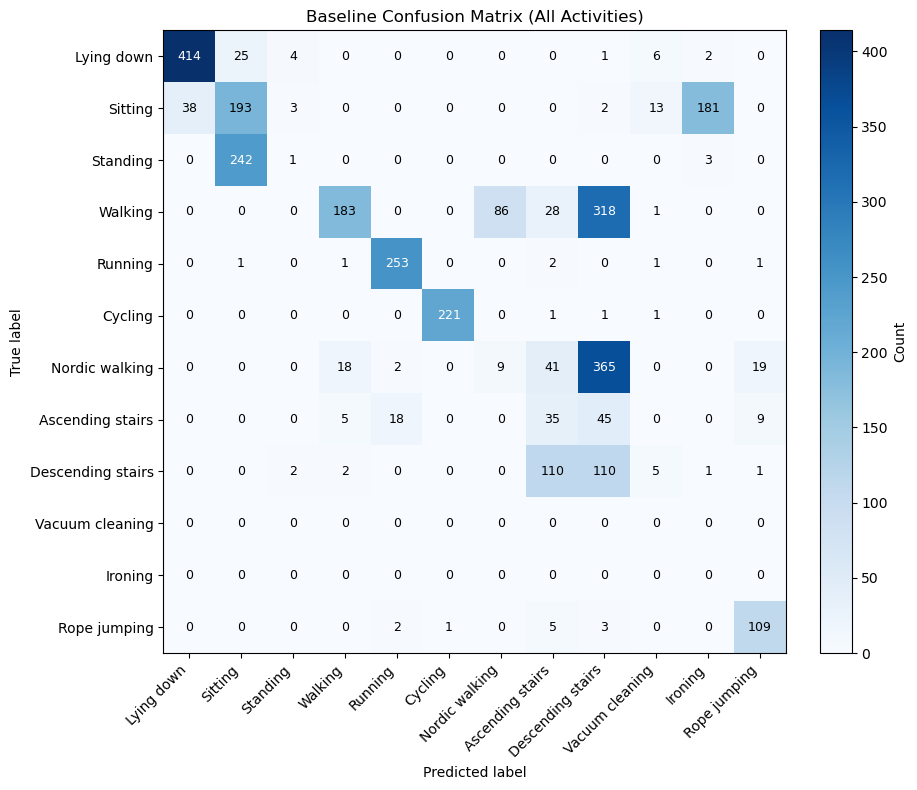

In [9]:
plot_cm(y_true_all,y_pred_all,labels,name_map,name='All Activities')
plot_cm_test(y_test,y_pred,labels,name_map,name='All Activities')


Confusion matrix (5-fold pooled predictions):
                     Standing  Running  Cycling  Ascending \nStairs  \
Standing                  334        0        0                   1   
Running                     0      740        0                   3   
Cycling                     0        0      715                 217   
Ascending \nStairs          0       21        2                 464   
Descending \nStairs         2       50        0                 233   
Rope \nJumping              0       22        1                   9   
Resting                   258        0        1                   1   
Walking                     1       10        2                 602   
House Work                218        0       37                 328   

                     Descending \nStairs  Rope \nJumping  Resting  Walking  \
Standing                               9               0      464        0   
Running                                6               2        1        2   
Cycling 

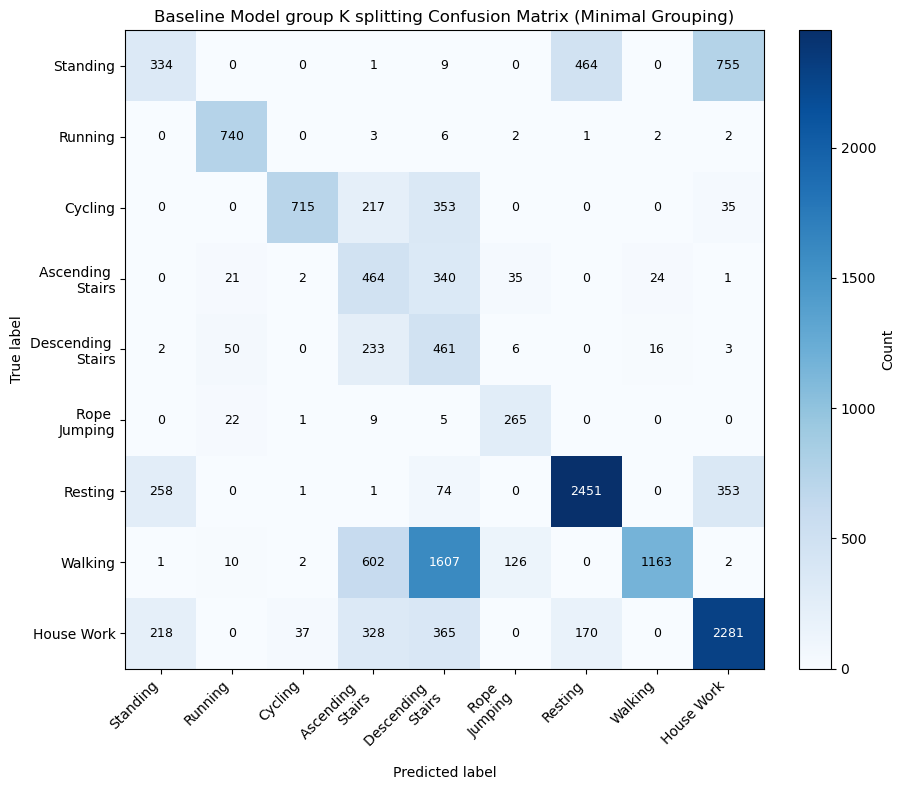


Confusion matrix (test set):
                     Standing  Running  Cycling  Ascending \nStairs  \
Standing                    6        0        0                   0   
Running                     0      253        0                   2   
Cycling                     0        0      222                   1   
Ascending \nStairs          0       18        0                  35   
Descending \nStairs         2        0        0                 113   
Rope \nJumping              0        2        1                   5   
Resting                     9        0        0                   1   
Walking                     0        1        0                  61   
House Work                  0        0        0                   0   

                     Descending \nStairs  Rope \nJumping  Resting  Walking  \
Standing                               0               0      235        0   
Running                                0               1        1        1   
Cycling                  

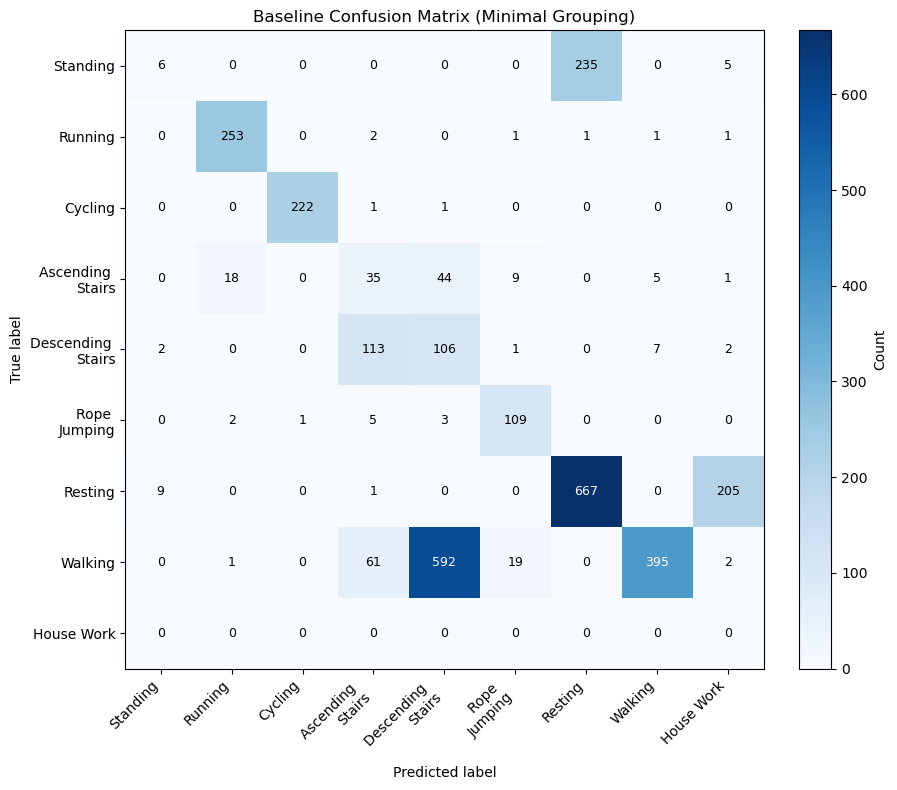

In [10]:
plot_cm(y_true_all_sim,y_pred_all_sim,labels_sim,name_map_sim,name='Minimal Grouping')
plot_cm_test(y_test_sim,y_pred_sim,labels_sim,name_map_sim,name='Minimal Grouping')


Confusion matrix (5-fold pooled predictions):
                   Low \nActivity  Medium \nActivity  High \nActivity
Low \nActivity               3708                954               39
Medium \nActivity             614               4455             3501
High \nActivity                 1                620             1757

Saved confusion group K split matrix PNG: baseline_group_K_split_confusion_matrix_LMH.png


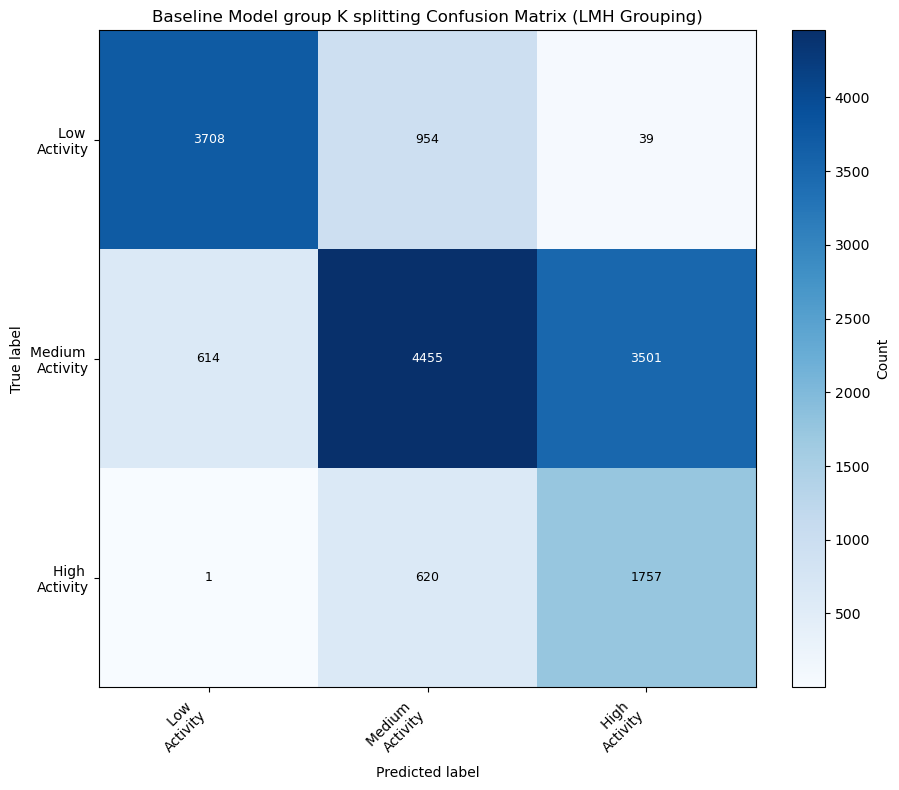


Confusion matrix (test set):
                   Low \nActivity  Medium \nActivity  High \nActivity
Low \nActivity               1055                 73                0
Medium \nActivity               2                533              878
High \nActivity                 1                 37              565

Saved confusion matrix PNG: baseline_confusion_matrix_LMH_grouping.png


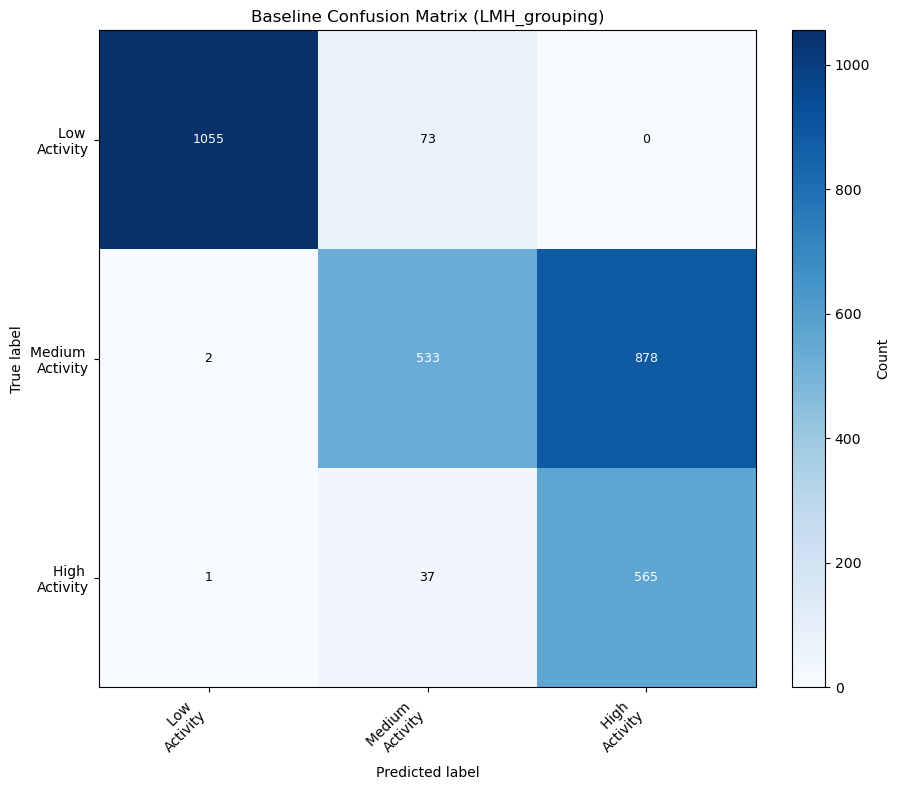

In [11]:
plot_cm(y_true_all_LMH,y_pred_all_LMH,labels_LMH,name_map_LMH,name='LMH Grouping')
plot_cm_test(y_test_LMH,y_pred_LMH,labels_LMH,name_map_LMH,name='LMH_grouping')